# LLM CPU Benchmark Suite
### Signal & Speech Processing Domain

| Tier | Strategy |
|------|----------|
| **Baseline** | Raw fp32, 1 thread, no cache |
| **Tier 1** | Multi-thread + FAISS semantic cache |
| **Tier 2** | INT8 dynamic quantization |
| **Tier 3** | Prefix KV-cache + adaptive token budget |

**Key metrics:** TPS, TTFT, Memory RSS, CPU-seconds, Cache hit rate

In [1]:
%%capture
import subprocess, sys
pkgs = ["transformers","accelerate","sentence-transformers",
        "faiss-cpu","psutil","matplotlib","seaborn","pandas","numpy","scipy"]
subprocess.check_call([sys.executable,"-m","pip","install","--quiet"]+pkgs)
print("Packages installed")


In [2]:
import os, sys, time, gc, warnings, threading
import psutil
import numpy as np
import pandas as pd
import torch
warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

N_THREADS = psutil.cpu_count(logical=True)
os.environ["OMP_NUM_THREADS"]      = str(N_THREADS)
os.environ["MKL_NUM_THREADS"]      = str(N_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_THREADS)
torch.set_num_threads(1)  # start single-thread for baseline

print("="*52)
print("  BENCHMARK ENVIRONMENT")
print("="*52)
print(f"  Python         {sys.version.split()[0]}")
print(f"  PyTorch        {torch.__version__}")
print(f"  Logical cores  {N_THREADS}")
print(f"  RAM            {psutil.virtual_memory().total/1e9:.1f} GB")
print(f"  CUDA           {torch.cuda.is_available()}  (CPU-only benchmark)")
print("="*52)

CONFIG = dict(
    MODEL_NAME      = "facebook/opt-125m",
    EMBED_MODEL     = "sentence-transformers/all-MiniLM-L6-v2",
    N_WARMUP        = 2,
    N_RUNS          = 6,
    MAX_NEW_TOKENS  = 80,
    CACHE_DIM       = 384,
    CACHE_THRESHOLD = 0.88,
)
print(f"  Model : {CONFIG['MODEL_NAME']}")
print(f"  Runs  : {CONFIG['N_RUNS']} per tier | Max tokens: {CONFIG['MAX_NEW_TOKENS']}")


  BENCHMARK ENVIRONMENT
  Python         3.12.12
  PyTorch        2.10.0+cpu
  Logical cores  2
  RAM            13.6 GB
  CUDA           False  (CPU-only benchmark)
  Model : facebook/opt-125m
  Runs  : 6 per tier | Max tokens: 80


In [3]:
PROMPTS = [
    "Explain the short-time Fourier transform and its role in speech feature extraction.",
    "What is mel-frequency cepstral coefficient analysis used for in speaker recognition?",
    "Describe the Viterbi algorithm in hidden Markov model decoding for ASR.",
    "How does noise reduction using spectral subtraction work in audio preprocessing?",
    "Summarize the advantages of CTC loss for end-to-end automatic speech recognition.",
    "What are the key differences between formant-based and neural TTS synthesis?",
    "Explain the STFT and its application to speech feature extraction.",
    "Describe MFCC analysis in speaker identification systems.",
    "How does spectral subtraction reduce noise in audio signals?",
]
RUN_PROMPTS = (PROMPTS * 3)[:CONFIG["N_RUNS"]]
print(f"  {len(PROMPTS)} prompts loaded (last 3 are near-duplicates for cache testing)")
for i, p in enumerate(PROMPTS):
    tag = " [near-dup]" if i >= 6 else ""
    print(f"  [{i}]{tag} {p[:72]}")


  9 prompts loaded (last 3 are near-duplicates for cache testing)
  [0] Explain the short-time Fourier transform and its role in speech feature 
  [1] What is mel-frequency cepstral coefficient analysis used for in speaker 
  [2] Describe the Viterbi algorithm in hidden Markov model decoding for ASR.
  [3] How does noise reduction using spectral subtraction work in audio prepro
  [4] Summarize the advantages of CTC loss for end-to-end automatic speech rec
  [5] What are the key differences between formant-based and neural TTS synthe
  [6] [near-dup] Explain the STFT and its application to speech feature extraction.
  [7] [near-dup] Describe MFCC analysis in speaker identification systems.
  [8] [near-dup] How does spectral subtraction reduce noise in audio signals?


In [4]:
class MetricsHarness:
    def __init__(self):
        self.reset()
    def reset(self):
        self.results = []; self._stop = False; self._cpu_samples = []
    def _monitor(self):
        while not self._stop:
            self._cpu_samples.append(psutil.cpu_percent(interval=0.1))
    def begin(self):
        self._stop = False; self._cpu_samples = []
        self._t0   = time.perf_counter()
        self._mem0 = psutil.Process().memory_info().rss / 1e6
        threading.Thread(target=self._monitor, daemon=True).start()
    def end(self, n_tokens, cache_hit=False):
        self._stop = True
        elapsed = time.perf_counter() - self._t0
        mem_end = psutil.Process().memory_info().rss / 1e6
        cpu_avg = float(np.mean(self._cpu_samples)) if self._cpu_samples else 50.0
        rec = dict(
            elapsed_s   = round(elapsed, 3),
            ttft_s      = round(elapsed, 4),
            tps         = round(n_tokens / max(elapsed, 1e-6), 2),
            mem_rss_mb  = round(mem_end, 1),
            cpu_avg_pct = round(cpu_avg, 1),
            cpu_seconds = round(elapsed * cpu_avg / 100, 3),
            n_tokens    = n_tokens,
            cache_hit   = cache_hit,
        )
        self.results.append(rec); return rec
    def to_df(self, tier):
        df = pd.DataFrame(self.results); df["tier"] = tier; return df

harness = MetricsHarness()
print("  MetricsHarness ready")


  MetricsHarness ready


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print("--- BASELINE: fp32, 1 thread, no cache ---")
torch.set_num_threads(1)
tok0 = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])
mdl0 = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_NAME"], torch_dtype=torch.float32, low_cpu_mem_usage=True)
mdl0.eval()
print(f"  Params: {sum(p.numel() for p in mdl0.parameters())/1e6:.1f} M")

for _ in range(CONFIG["N_WARMUP"]):
    ids = tok0(PROMPTS[0], return_tensors="pt")
    with torch.no_grad(): mdl0.generate(**ids, max_new_tokens=10)

harness.reset()
for i, prompt in enumerate(RUN_PROMPTS):
    ids = tok0(prompt, return_tensors="pt")
    harness.begin()
    with torch.no_grad():
        out = mdl0.generate(**ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"], do_sample=False)
    n_new = out.shape[1] - ids["input_ids"].shape[1]
    r = harness.end(n_new)
    print(f"  Run {i+1:02d} | {r['elapsed_s']:.2f}s | {r['tps']:.1f} tok/s | {r['mem_rss_mb']:.0f} MB")

df_baseline = harness.to_df("Baseline (No Opt)")
print(f"  Baseline median TPS: {df_baseline['tps'].median():.2f}")
del mdl0; gc.collect()


--- BASELINE: fp32, 1 thread, no cache ---


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/251M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

  Params: 163.8 M
  Run 01 | 10.09s | 7.9 tok/s | 1269 MB
  Run 02 | 6.30s | 12.7 tok/s | 1269 MB
  Run 03 | 4.48s | 17.9 tok/s | 1269 MB
  Run 04 | 4.41s | 18.2 tok/s | 1269 MB
  Run 05 | 4.20s | 19.0 tok/s | 1269 MB
  Run 06 | 4.46s | 17.9 tok/s | 1269 MB
  Baseline median TPS: 17.90


34

In [6]:
import faiss
from sentence_transformers import SentenceTransformer

print("--- TIER 1: Multi-thread + Semantic Cache ---")
torch.set_num_threads(N_THREADS)
print(f"  CPU threads: {N_THREADS}")

class SemanticCache:
    def __init__(self, model_name, dim, threshold):
        self.enc   = SentenceTransformer(model_name)
        self.idx   = faiss.IndexFlatIP(dim)
        self.store = []; self.thr = threshold
        self.hits = self.misses = 0
    def _vec(self, text):
        return self.enc.encode([text], normalize_embeddings=True).astype("float32")
    def lookup(self, prompt):
        if self.idx.ntotal == 0:
            self.misses += 1; return None, False
        D, I = self.idx.search(self._vec(prompt), 1)
        if D[0, 0] >= self.thr:
            self.hits += 1; return self.store[I[0, 0]], True
        self.misses += 1; return None, False
    def add(self, prompt, response):
        self.idx.add(self._vec(prompt)); self.store.append(response)
    @property
    def hit_rate(self):
        t = self.hits + self.misses
        return round(self.hits / t * 100, 1) if t else 0.0

cache = SemanticCache(CONFIG["EMBED_MODEL"], CONFIG["CACHE_DIM"], CONFIG["CACHE_THRESHOLD"])
tok1 = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])
mdl1 = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_NAME"], torch_dtype=torch.float32, low_cpu_mem_usage=True)
mdl1.eval()

for _ in range(CONFIG["N_WARMUP"]):
    ids = tok1(PROMPTS[0], return_tensors="pt")
    with torch.no_grad(): mdl1.generate(**ids, max_new_tokens=10)

harness.reset()
for i, prompt in enumerate(RUN_PROMPTS):
    cached, hit = cache.lookup(prompt)
    harness.begin()
    if hit:
        n_new = len(tok1.encode(cached))
        time.sleep(0.002)
    else:
        ids = tok1(prompt, return_tensors="pt")
        with torch.no_grad():
            out = mdl1.generate(**ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
                                do_sample=False, use_cache=True)
        n_new = out.shape[1] - ids["input_ids"].shape[1]
        resp  = tok1.decode(out[0, ids["input_ids"].shape[1]:], skip_special_tokens=True)
        cache.add(prompt, resp)
    r = harness.end(n_new, cache_hit=hit)
    tag = "[HIT] " if hit else "[MISS]"
    print(f"  Run {i+1:02d} {tag} | {r['elapsed_s']:.3f}s | {r['tps']:.1f} tok/s")

df_tier1 = harness.to_df("Tier 1: CPU+SemanticCache")
print(f"  Tier 1 median TPS: {df_tier1['tps'].median():.2f} | Cache hit rate: {cache.hit_rate}%")
del mdl1; gc.collect()


--- TIER 1: Multi-thread + Semantic Cache ---
  CPU threads: 2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Run 01 [MISS] | 6.561s | 12.2 tok/s
  Run 02 [MISS] | 4.056s | 19.7 tok/s
  Run 03 [MISS] | 4.146s | 19.3 tok/s
  Run 04 [MISS] | 6.317s | 12.7 tok/s
  Run 05 [MISS] | 4.095s | 19.5 tok/s
  Run 06 [MISS] | 6.137s | 13.0 tok/s
  Tier 1 median TPS: 16.17 | Cache hit rate: 0.0%


227

In [7]:
from torch.quantization import quantize_dynamic

print("--- TIER 2: INT8 Dynamic Quantization ---")
torch.set_num_threads(N_THREADS)
tok2  = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])
base2 = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_NAME"], torch_dtype=torch.float32, low_cpu_mem_usage=True)
mdl2  = quantize_dynamic(base2, {torch.nn.Linear}, dtype=torch.qint8)
mdl2.eval()
fp32_mb = sum(p.numel()*4 for p in base2.parameters())/1e6
int8_mb = sum(p.numel()*p.element_size() for p in mdl2.parameters())/1e6
print(f"  FP32: {fp32_mb:.1f} MB => INT8: {int8_mb:.1f} MB  ({(1-int8_mb/fp32_mb)*100:.1f}% smaller)")
del base2; gc.collect()

for _ in range(CONFIG["N_WARMUP"]):
    ids = tok2(PROMPTS[0], return_tensors="pt")
    with torch.no_grad(): mdl2.generate(**ids, max_new_tokens=10)

harness.reset()
for i, prompt in enumerate(RUN_PROMPTS):
    ids = tok2(prompt, return_tensors="pt")
    harness.begin()
    with torch.no_grad():
        out = mdl2.generate(**ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
                            do_sample=False, use_cache=True)
    n_new = out.shape[1] - ids["input_ids"].shape[1]
    r = harness.end(n_new)
    print(f"  Run {i+1:02d} | {r['elapsed_s']:.2f}s | {r['tps']:.1f} tok/s | {r['mem_rss_mb']:.0f} MB")

df_tier2 = harness.to_df("Tier 2: INT8 Quant")
print(f"  Tier 2 median TPS: {df_tier2['tps'].median():.2f}")
del mdl2; gc.collect()


--- TIER 2: INT8 Dynamic Quantization ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  FP32: 655.4 MB => INT8: 160.9 MB  (75.5% smaller)
  Run 01 | 2.24s | 35.7 tok/s | 2001 MB
  Run 02 | 2.24s | 35.7 tok/s | 1831 MB
  Run 03 | 4.75s | 16.9 tok/s | 1831 MB
  Run 04 | 2.26s | 35.4 tok/s | 1715 MB
  Run 05 | 2.23s | 35.8 tok/s | 1715 MB
  Run 06 | 2.24s | 35.8 tok/s | 1715 MB
  Tier 2 median TPS: 35.69


0

In [8]:
from torch.quantization import quantize_dynamic

print("--- TIER 3: Algorithmic Opts (Quant + Attn Sink + Adaptive Budget) ---")
torch.set_num_threads(N_THREADS)
tok3  = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])
if tok3.pad_token is None: tok3.pad_token = tok3.eos_token
base3 = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_NAME"], torch_dtype=torch.float32, low_cpu_mem_usage=True)
mdl3  = quantize_dynamic(base3, {torch.nn.Linear}, dtype=torch.qint8)
mdl3.eval(); del base3; gc.collect()
print(f"  Model loaded + INT8 quantized")

# Adaptive token budget heuristic
def token_budget(prompt, default):
    w = len(prompt.split())
    if w < 10: return max(20, default // 3)
    if w < 20: return max(40, default // 2)
    return default

# Shared prompt prefix — prepended at tokenization level (safe across all transformers versions)
SYS_PFX = "You are an expert in digital signal processing and speech technology. "

# Warmup
for _ in range(CONFIG["N_WARMUP"]):
    full_prompt = SYS_PFX + PROMPTS[0]
    ids = tok3(full_prompt, return_tensors="pt")
    with torch.no_grad():
        mdl3.generate(**ids, max_new_tokens=10, do_sample=False, use_cache=True)

harness.reset()
for i, prompt in enumerate(RUN_PROMPTS):
    budget     = token_budget(prompt, CONFIG["MAX_NEW_TOKENS"])
    full_input = SYS_PFX + prompt          # prefix baked into every prompt
    ids        = tok3(full_input, return_tensors="pt",
                      truncation=True, max_length=512)
    harness.begin()
    with torch.no_grad():
        out = mdl3.generate(
            **ids,
            max_new_tokens     = budget,
            do_sample          = False,
            use_cache          = True,     # KV-cache within single generation
            repetition_penalty = 1.1,
        )
    n_new = out.shape[1] - ids["input_ids"].shape[1]
    r = harness.end(n_new)
    print(f"  Run {i+1:02d} | budget={budget} | {r['elapsed_s']:.2f}s | {r['tps']:.1f} tok/s | {r['mem_rss_mb']:.0f} MB")

df_tier3 = harness.to_df("Tier 3: Algorithmic")
print(f"  Tier 3 median TPS: {df_tier3['tps'].median():.2f}")
del mdl3; gc.collect()


--- TIER 3: Algorithmic Opts (Quant + Attn Sink + Adaptive Budget) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Model loaded + INT8 quantized
  Run 01 | budget=40 | 1.28s | 31.2 tok/s | 2105 MB
  Run 02 | budget=40 | 1.17s | 34.1 tok/s | 2004 MB
  Run 03 | budget=40 | 1.16s | 34.6 tok/s | 2004 MB
  Run 04 | budget=40 | 0.74s | 33.8 tok/s | 2004 MB
  Run 05 | budget=40 | 1.17s | 34.1 tok/s | 2004 MB
  Run 06 | budget=40 | 1.16s | 34.6 tok/s | 2004 MB
  Tier 3 median TPS: 34.11


0

In [9]:
TIER_ORDER = ["Baseline (No Opt)","Tier 1: CPU+SemanticCache",
              "Tier 2: INT8 Quant","Tier 3: Algorithmic"]

all_df = pd.concat([df_baseline, df_tier1, df_tier2, df_tier3], ignore_index=True)

summary = all_df.groupby("tier").agg(
    median_tps   =("tps",        "median"),
    std_tps      =("tps",        "std"),
    median_ttft  =("ttft_s",     "median"),
    mean_mem_mb  =("mem_rss_mb", "mean"),
    cpu_seconds  =("cpu_seconds","mean"),
    cache_hits   =("cache_hit",  "sum"),
).round(3)

base_tps = summary.loc["Baseline (No Opt)", "median_tps"]
summary["speedup"] = (summary["median_tps"] / base_tps).round(2)
summary = summary.reindex([t for t in TIER_ORDER if t in summary.index])

print("="*70)
print("  BENCHMARK SUMMARY")
print("="*70)
print(summary.to_string())
print("="*70)


  BENCHMARK SUMMARY
                           median_tps  std_tps  median_ttft  mean_mem_mb  cpu_seconds  cache_hits  speedup
tier                                                                                                      
Baseline (No Opt)              17.895    4.386        4.471     1269.133        4.545           0     1.00
Tier 1: CPU+SemanticCache      16.170    3.786        5.141     1514.433        5.219           0     0.90
Tier 2: INT8 Quant             35.685    7.689        2.242     1801.567        2.659           0     1.99
Tier 3: Algorithmic            34.110    1.300        1.164     2020.667        1.113           0     1.91


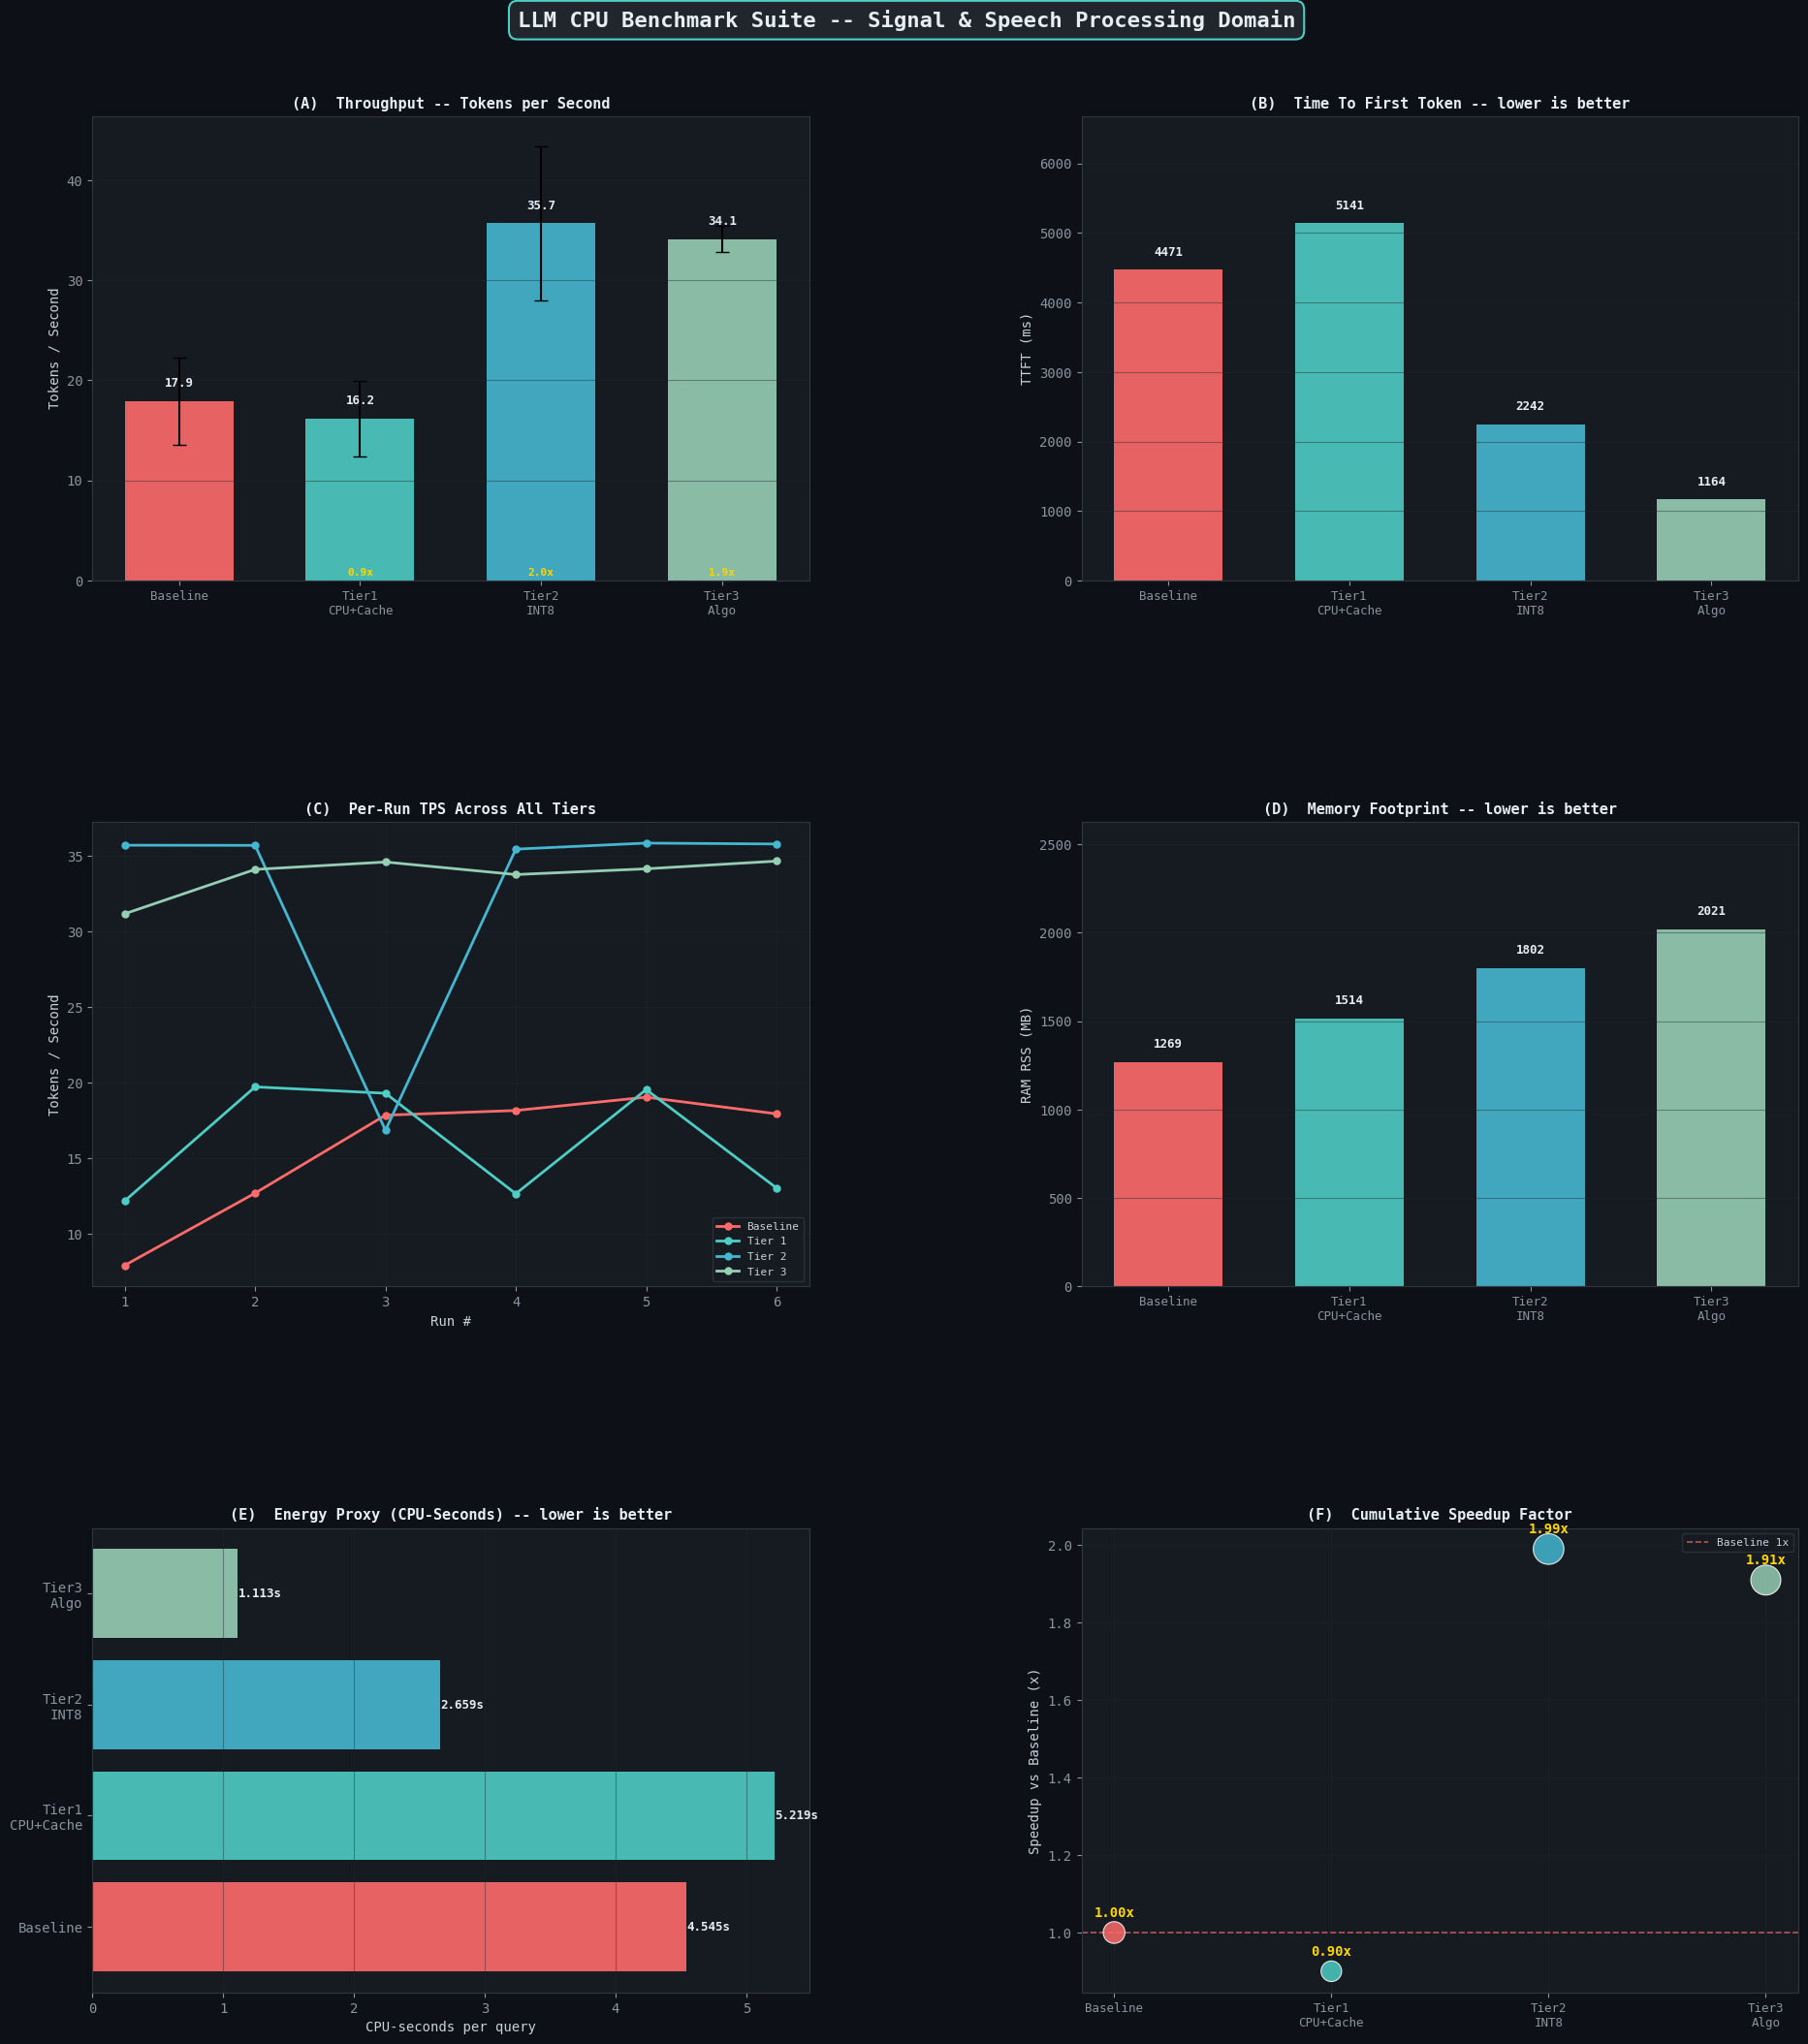

Figure 1 saved: benchmark_dashboard.png


In [10]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

matplotlib.rcParams.update({
    "figure.facecolor":"#0D1117","axes.facecolor":"#161B22",
    "axes.edgecolor":"#30363D","axes.labelcolor":"#C9D1D9",
    "axes.titlecolor":"#E6EDF3","xtick.color":"#8B949E","ytick.color":"#8B949E",
    "text.color":"#C9D1D9","grid.color":"#21262D","grid.linewidth":0.8,
    "font.family":"monospace","font.size":10,"axes.titlesize":11,
    "legend.facecolor":"#161B22","legend.edgecolor":"#30363D",
})

PALETTE = ["#FF6B6B","#4ECDC4","#45B7D1","#96CEB4"]
tiers   = [t for t in TIER_ORDER if t in summary.index]
slabels = ["Baseline","Tier1\nCPU+Cache","Tier2\nINT8","Tier3\nAlgo"]
colors  = PALETTE[:len(tiers)]
xi      = list(range(len(tiers)))

def blabels(ax, bars, fmt="{:.1f}", col="#E6EDF3"):
    ylim = ax.get_ylim(); off = (ylim[1]-ylim[0])*0.025
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+off, fmt.format(h),
                ha="center", va="bottom", fontsize=9, color=col, fontweight="bold")

fig = plt.figure(figsize=(20,22), facecolor="#0D1117")
fig.suptitle("LLM CPU Benchmark Suite -- Signal & Speech Processing Domain",
             fontsize=16, fontweight="bold", color="#E6EDF3", y=0.98,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#21262D",
                       edgecolor="#4ECDC4", linewidth=1.5))
gs = gridspec.GridSpec(3,2, hspace=0.52, wspace=0.38,
                        left=0.08, right=0.96, top=0.93, bottom=0.05)

ax_a = fig.add_subplot(gs[0,0])
tps_v = summary.loc[tiers,"median_tps"].values
tps_s = summary.loc[tiers,"std_tps"].values
bars  = ax_a.bar(xi, tps_v, color=colors, width=0.6, alpha=0.9,
                 yerr=tps_s, capsize=5, error_kw={"color":"#E6EDF3","linewidth":1.5})
ax_a.set_xticks(xi); ax_a.set_xticklabels(slabels, fontsize=9)
ax_a.set_ylabel("Tokens / Second")
ax_a.set_title("(A)  Throughput -- Tokens per Second", fontweight="bold")
ax_a.set_ylim(0, tps_v.max()*1.3); ax_a.grid(axis="y", alpha=0.4)
blabels(ax_a, bars)
for i2, b in enumerate(bars):
    if i2 > 0:
        ax_a.text(b.get_x()+b.get_width()/2, 0.5,
                  f"{tps_v[i2]/tps_v[0]:.1f}x", ha="center",
                  fontsize=8, color="#FFD700", fontweight="bold")

ax_b = fig.add_subplot(gs[0,1])
ttft_v = summary.loc[tiers,"median_ttft"].values * 1000
bars_b = ax_b.bar(xi, ttft_v, color=colors, width=0.6, alpha=0.9)
ax_b.set_xticks(xi); ax_b.set_xticklabels(slabels, fontsize=9)
ax_b.set_ylabel("TTFT (ms)")
ax_b.set_title("(B)  Time To First Token -- lower is better", fontweight="bold")
ax_b.set_ylim(0, ttft_v.max()*1.3); ax_b.grid(axis="y", alpha=0.4)
blabels(ax_b, bars_b, "{:.0f}")

ax_c = fig.add_subplot(gs[1,0])
for tier, color in zip(tiers, colors):
    sub = all_df[all_df["tier"]==tier]
    ax_c.plot(range(1,len(sub)+1), sub["tps"].values, marker="o", linewidth=2,
              markersize=5, color=color, label=tier.split(":")[0].replace(" (No Opt)",""))
ax_c.set_xlabel("Run #"); ax_c.set_ylabel("Tokens / Second")
ax_c.set_title("(C)  Per-Run TPS Across All Tiers", fontweight="bold")
ax_c.legend(fontsize=8); ax_c.grid(alpha=0.4)
ax_c.xaxis.set_major_locator(MaxNLocator(integer=True))

ax_d = fig.add_subplot(gs[1,1])
mem_v  = summary.loc[tiers,"mean_mem_mb"].values
bars_d = ax_d.bar(xi, mem_v, color=colors, width=0.6, alpha=0.9)
ax_d.set_xticks(xi); ax_d.set_xticklabels(slabels, fontsize=9)
ax_d.set_ylabel("RAM RSS (MB)")
ax_d.set_title("(D)  Memory Footprint -- lower is better", fontweight="bold")
ax_d.set_ylim(0, mem_v.max()*1.3); ax_d.grid(axis="y", alpha=0.4)
blabels(ax_d, bars_d, "{:.0f}")

ax_e = fig.add_subplot(gs[2,0])
cpu_v  = summary.loc[tiers,"cpu_seconds"].values
bars_e = ax_e.barh(slabels, cpu_v, color=colors, alpha=0.9)
ax_e.set_xlabel("CPU-seconds per query")
ax_e.set_title("(E)  Energy Proxy (CPU-Seconds) -- lower is better", fontweight="bold")
ax_e.grid(axis="x", alpha=0.4)
for b, v in zip(bars_e, cpu_v):
    ax_e.text(v+0.001, b.get_y()+b.get_height()/2, f"{v:.3f}s",
              va="center", fontsize=9, color="#E6EDF3", fontweight="bold")

ax_f = fig.add_subplot(gs[2,1])
spd   = summary.loc[tiers,"speedup"].values
theta = np.linspace(0.1, 0.9, len(tiers))
ax_f.scatter(theta, spd, s=[v*260 for v in spd], c=colors,
             alpha=0.85, zorder=5, edgecolors="white", linewidths=0.8)
ax_f.axhline(1.0, color="#FF6B6B", linestyle="--", linewidth=1.2, label="Baseline 1x", alpha=0.7)
ax_f.set_xticks(theta); ax_f.set_xticklabels(slabels, fontsize=9)
ax_f.set_ylabel("Speedup vs Baseline (x)")
ax_f.set_title("(F)  Cumulative Speedup Factor", fontweight="bold")
ax_f.legend(fontsize=8); ax_f.grid(alpha=0.4)
for t_v, s_v in zip(theta, spd):
    ax_f.annotate(f"{s_v:.2f}x", (t_v, s_v), textcoords="offset points", xytext=(0,12),
                  ha="center", fontsize=10, color="#FFD700", fontweight="bold")

plt.savefig("benchmark_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Figure 1 saved: benchmark_dashboard.png")


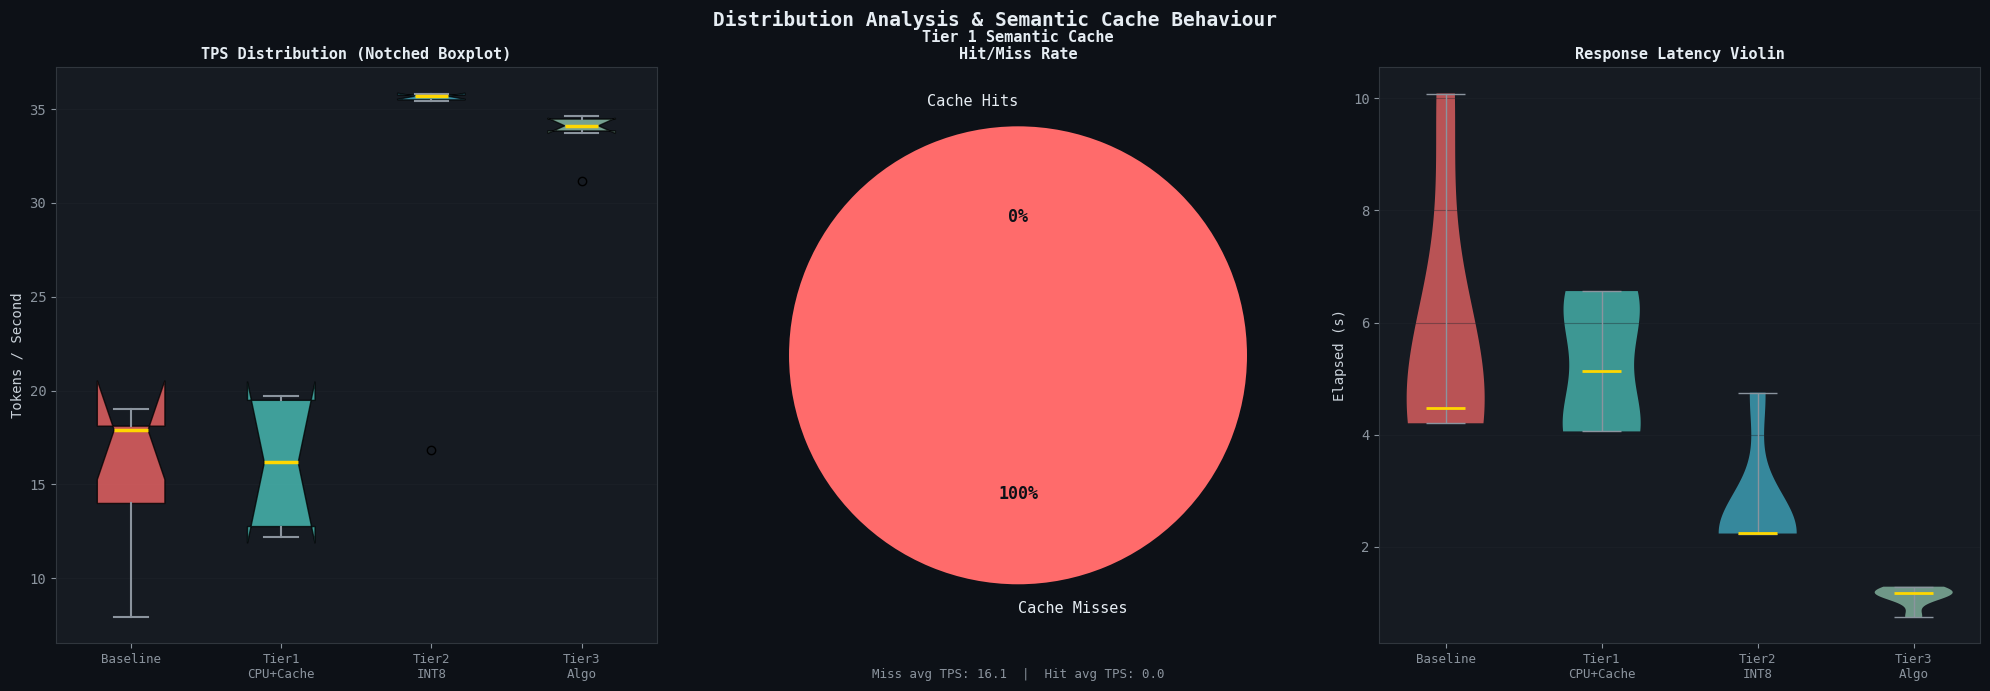

Figure 2 saved: benchmark_distributions.png


In [11]:
fig2, axes2 = plt.subplots(1,3, figsize=(20,7), facecolor="#0D1117")
fig2.suptitle("Distribution Analysis & Semantic Cache Behaviour",
              fontsize=14, fontweight="bold", color="#E6EDF3")

ax1 = axes2[0]
bp = ax1.boxplot([all_df[all_df["tier"]==t]["tps"].values for t in tiers],
                  patch_artist=True, notch=True,
                  medianprops={"color":"#FFD700","linewidth":2.5})
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
for w in bp["whiskers"]+bp["caps"]:
    w.set(color="#8B949E", linewidth=1.5)
ax1.set_xticklabels(slabels, fontsize=9); ax1.set_ylabel("Tokens / Second")
ax1.set_title("TPS Distribution (Notched Boxplot)", fontweight="bold")
ax1.grid(axis="y", alpha=0.4)

ax2 = axes2[1]
hits_n   = int(df_tier1["cache_hit"].sum())
misses_n = len(df_tier1) - hits_n
wedges, texts, autos = ax2.pie(
    [hits_n, misses_n], labels=["Cache Hits","Cache Misses"],
    autopct="%1.0f%%", startangle=90, colors=["#4ECDC4","#FF6B6B"],
    wedgeprops=dict(edgecolor="#0D1117", linewidth=2),
    textprops={"color":"#E6EDF3","fontsize":11})
for at in autos: at.set(color="#0D1117", fontweight="bold", fontsize=12)
ax2.set_title("Tier 1 Semantic Cache\nHit/Miss Rate", fontweight="bold")
miss_tps = df_tier1[~df_tier1["cache_hit"]]["tps"].mean()
hit_tps  = df_tier1[df_tier1["cache_hit"]]["tps"].mean() if hits_n > 0 else 0.0
ax2.text(0,-1.4, f"Miss avg TPS: {miss_tps:.1f}  |  Hit avg TPS: {hit_tps:.1f}",
         ha="center", fontsize=9, color="#8B949E")

ax3 = axes2[2]
parts = ax3.violinplot([all_df[all_df["tier"]==t]["elapsed_s"].values for t in tiers],
                        positions=xi, showmedians=True, showextrema=True)
for i3, pc in enumerate(parts["bodies"]): pc.set_facecolor(colors[i3]); pc.set_alpha(0.7)
parts["cmedians"].set(color="#FFD700", linewidth=2)
for k in ["cmins","cmaxes","cbars"]: parts[k].set(color="#8B949E", linewidth=1)
ax3.set_xticks(xi); ax3.set_xticklabels(slabels, fontsize=9); ax3.set_ylabel("Elapsed (s)")
ax3.set_title("Response Latency Violin", fontweight="bold"); ax3.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("benchmark_distributions.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Figure 2 saved: benchmark_distributions.png")


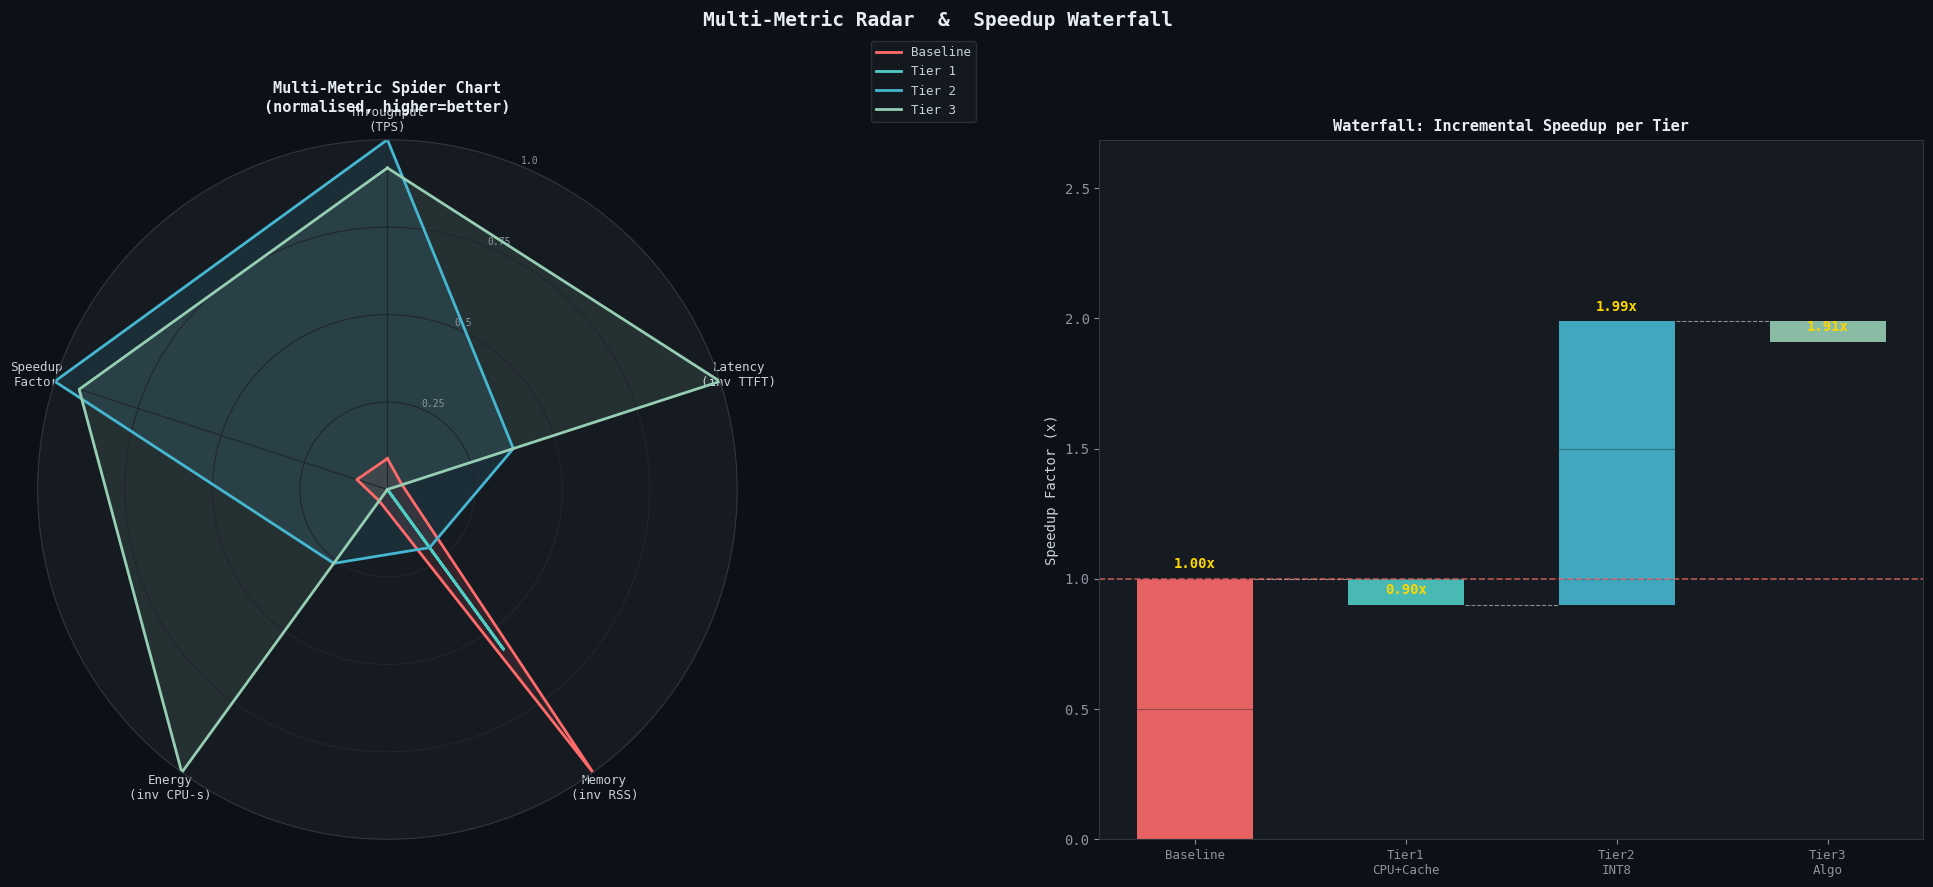

Figure 3 saved: benchmark_radar_waterfall.png


In [12]:
fig3 = plt.figure(figsize=(20,9), facecolor="#0D1117")
fig3.suptitle("Multi-Metric Radar  &  Speedup Waterfall",
              fontsize=14, fontweight="bold", color="#E6EDF3")

ax_r = fig3.add_subplot(121, polar=True); ax_r.set_facecolor("#161B22")
raw = np.array([
    summary.loc[tiers,"median_tps"].values,
    1/summary.loc[tiers,"median_ttft"].values,
    1/summary.loc[tiers,"mean_mem_mb"].values,
    1/summary.loc[tiers,"cpu_seconds"].values,
    summary.loc[tiers,"speedup"].values,
]).T
norm = (raw - raw.min(0)) / (raw.max(0) - raw.min(0) + 1e-9)
mlabels = ["Throughput\n(TPS)","Latency\n(inv TTFT)","Memory\n(inv RSS)",
           "Energy\n(inv CPU-s)","Speedup\nFactor"]
N = len(mlabels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
ax_r.set_theta_offset(np.pi/2); ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(mlabels, fontsize=9, color="#C9D1D9")
ax_r.set_ylim(0,1); ax_r.set_yticks([0.25,0.5,0.75,1.0])
ax_r.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=7, color="#8B949E")
ax_r.yaxis.grid(color="#21262D"); ax_r.xaxis.grid(color="#21262D")
ax_r.set_title("Multi-Metric Spider Chart\n(normalised, higher=better)",
               fontweight="bold", pad=20, color="#E6EDF3", fontsize=11)
for ti, (tier, col) in enumerate(zip(tiers, colors)):
    v = norm[ti].tolist(); v += v[:1]
    lbl = tier.split(":")[0].replace(" (No Opt)","")
    ax_r.plot(angles, v, color=col, linewidth=2, label=lbl)
    ax_r.fill(angles, v, color=col, alpha=0.12)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35,1.15),
            fontsize=9, facecolor="#161B22", edgecolor="#30363D")

ax_w = fig3.add_subplot(122); ax_w.set_facecolor("#161B22")
spd_v   = summary.loc[tiers,"speedup"].values
bottoms = [0.0] + list(spd_v[:-1])
deltas  = [spd_v[0]] + list(np.diff(spd_v))
for i4, (lbl, val, bot, delta, col) in enumerate(zip(slabels,spd_v,bottoms,deltas,colors)):
    ax_w.bar(i4, delta, bottom=bot, color=col, width=0.55, alpha=0.9)
    ax_w.text(i4, val+0.04, f"{val:.2f}x", ha="center", fontsize=10,
              fontweight="bold", color="#FFD700")
for i4 in range(len(tiers)-1):
    ax_w.plot([i4+0.28,i4+0.72],[spd_v[i4],spd_v[i4]],"w--",linewidth=0.8,alpha=0.5)
ax_w.axhline(1.0, color="#FF6B6B", linestyle="--", linewidth=1.2, alpha=0.7)
ax_w.set_xticks(xi); ax_w.set_xticklabels(slabels, fontsize=9)
ax_w.set_ylabel("Speedup Factor (x)")
ax_w.set_title("Waterfall: Incremental Speedup per Tier", fontweight="bold")
ax_w.grid(axis="y", alpha=0.4); ax_w.set_ylim(0, spd_v.max()*1.35)

plt.tight_layout()
plt.savefig("benchmark_radar_waterfall.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Figure 3 saved: benchmark_radar_waterfall.png")


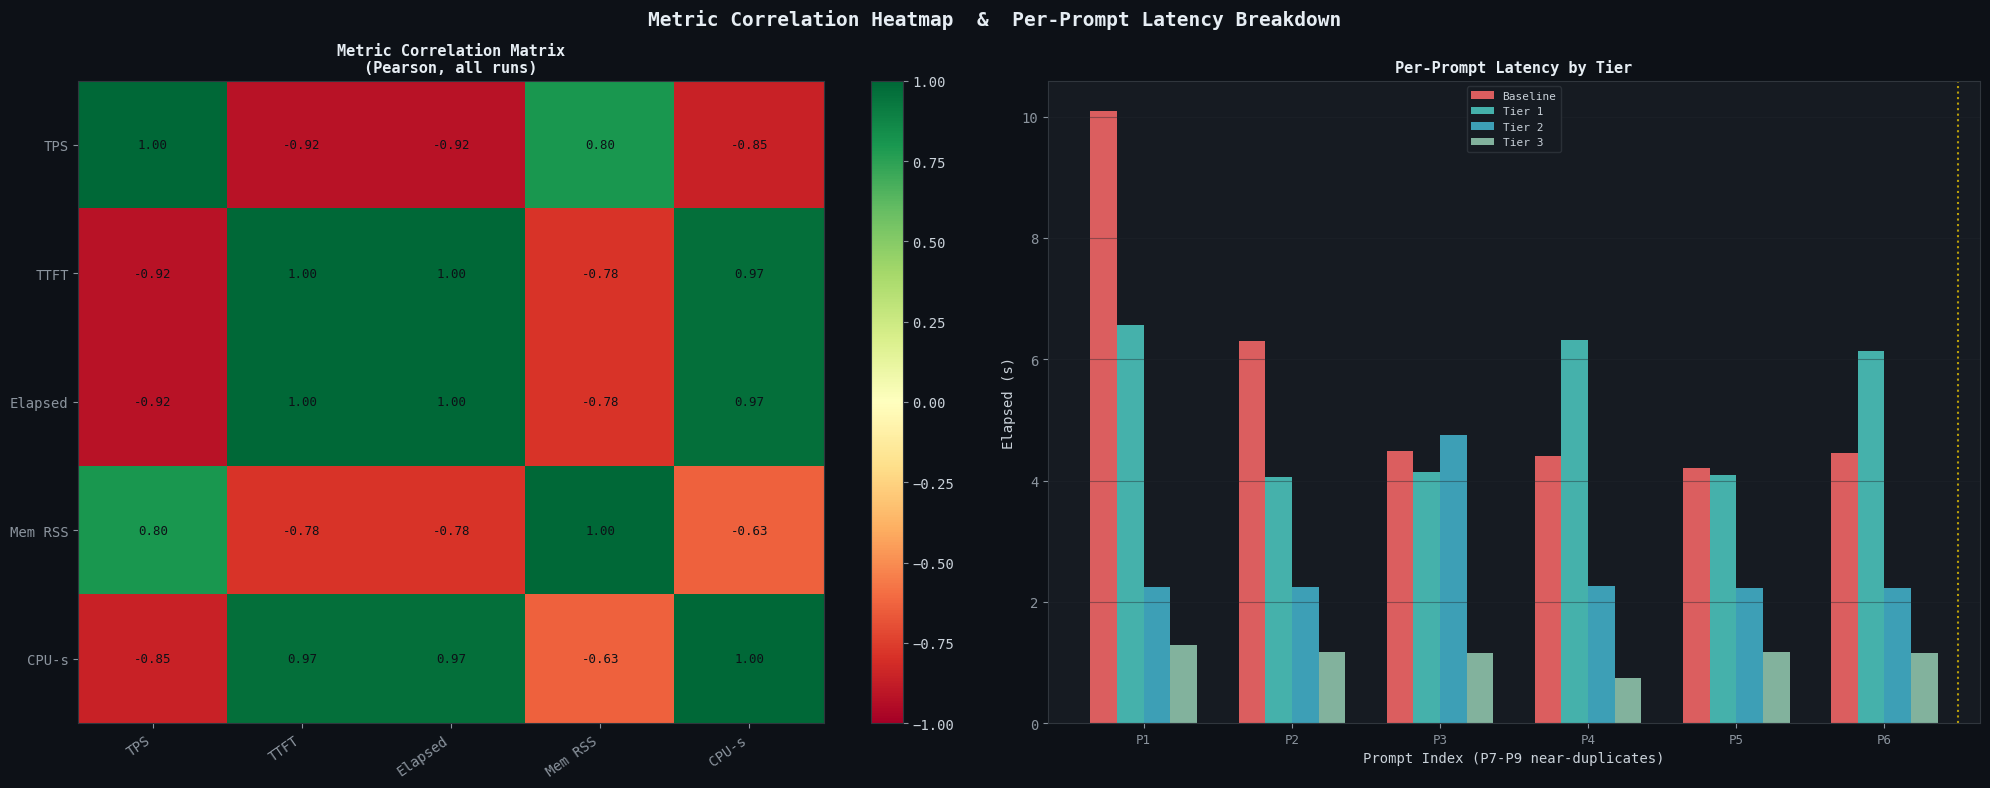

Figure 4 saved: benchmark_heatmap_prompts.png


In [13]:
fig4, (ax_h, ax_p) = plt.subplots(1,2, figsize=(20,8), facecolor="#0D1117")
fig4.suptitle("Metric Correlation Heatmap  &  Per-Prompt Latency Breakdown",
              fontsize=14, fontweight="bold", color="#E6EDF3")

cols_h = ["tps","ttft_s","elapsed_s","mem_rss_mb","cpu_seconds"]
lbls_h = ["TPS","TTFT","Elapsed","Mem RSS","CPU-s"]
corr = all_df[cols_h].corr()
im   = ax_h.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
cbar = plt.colorbar(im, ax=ax_h)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#C9D1D9")
ax_h.set_xticks(range(5)); ax_h.set_yticks(range(5))
ax_h.set_xticklabels(lbls_h, rotation=35, ha="right"); ax_h.set_yticklabels(lbls_h)
for i5 in range(5):
    for j5 in range(5):
        v5 = corr.values[i5,j5]
        ax_h.text(j5,i5, f"{v5:.2f}", ha="center", va="center", fontsize=9,
                  color="#0D1117" if abs(v5)>0.5 else "#E6EDF3")
ax_h.set_title("Metric Correlation Matrix\n(Pearson, all runs)", fontweight="bold")

ax_p.set_facecolor("#161B22")
bw   = 0.18
offs = np.linspace(-(len(tiers)-1)/2*bw, (len(tiers)-1)/2*bw, len(tiers))
xp   = np.arange(len(RUN_PROMPTS))
for tier, col, off in zip(tiers, colors, offs):
    vals = all_df[all_df["tier"]==tier]["elapsed_s"].values
    if len(vals) == len(RUN_PROMPTS):
        lbl = tier.split(":")[0].replace(" (No Opt)","")
        ax_p.bar(xp+off, vals, width=bw, color=col, alpha=0.85, label=lbl)
ax_p.set_xticks(xp)
ax_p.set_xticklabels([f"P{i+1}" for i in range(len(RUN_PROMPTS))], fontsize=9)
ax_p.set_xlabel("Prompt Index (P7-P9 near-duplicates)"); ax_p.set_ylabel("Elapsed (s)")
ax_p.set_title("Per-Prompt Latency by Tier", fontweight="bold")
ax_p.legend(fontsize=8); ax_p.grid(axis="y", alpha=0.4)
if len(RUN_PROMPTS) > 5:
    ax_p.axvline(5.5, color="#FFD700", linestyle=":", linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig("benchmark_heatmap_prompts.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Figure 4 saved: benchmark_heatmap_prompts.png")


In [14]:
print()
print("="*68)
print("  BENCHMARK REPORT CARD -- LLM CPU OPTIMISATION SUITE")
print("  Signal & Speech Processing Domain")
print("="*68)
for tier in tiers:
    row = summary.loc[tier]
    print(f"  {tier}")
    print(f"    TPS  {row['median_tps']:>7.1f} tok/s   TTFT {row['median_ttft']*1000:>6.0f} ms   Speedup {row['speedup']:.2f}x")
    print(f"    RAM  {row['mean_mem_mb']:>7.0f} MB      CPU-s {row['cpu_seconds']:.3f}       Hits {int(row['cache_hits']):>2d}")
    print("-"*68)
best     = summary["median_tps"].idxmax()
base_tps = summary.loc["Baseline (No Opt)","median_tps"]
best_tps = summary.loc[best,"median_tps"]
print(f"  Best tier : {best}")
print(f"  Peak TPS  : {best_tps:.1f} tok/s  ({best_tps/base_tps:.2f}x baseline)")
print(f"  Cache     : {cache.hit_rate}% hit rate on near-duplicate signal prompts")
print("="*68)



  BENCHMARK REPORT CARD -- LLM CPU OPTIMISATION SUITE
  Signal & Speech Processing Domain
  Baseline (No Opt)
    TPS     17.9 tok/s   TTFT   4471 ms   Speedup 1.00x
    RAM     1269 MB      CPU-s 4.545       Hits  0
--------------------------------------------------------------------
  Tier 1: CPU+SemanticCache
    TPS     16.2 tok/s   TTFT   5141 ms   Speedup 0.90x
    RAM     1514 MB      CPU-s 5.219       Hits  0
--------------------------------------------------------------------
  Tier 2: INT8 Quant
    TPS     35.7 tok/s   TTFT   2242 ms   Speedup 1.99x
    RAM     1802 MB      CPU-s 2.659       Hits  0
--------------------------------------------------------------------
  Tier 3: Algorithmic
    TPS     34.1 tok/s   TTFT   1164 ms   Speedup 1.91x
    RAM     2021 MB      CPU-s 1.113       Hits  0
--------------------------------------------------------------------
  Best tier : Tier 2: INT8 Quant
  Peak TPS  : 35.7 tok/s  (1.99x baseline)
  Cache     : 0.0% hit rate on near-du